In [36]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt



# Load media
book_img = cv.imread("cv_cover.jpg")
book_video = cv.VideoCapture("book.mov")
ar_video = cv.VideoCapture("ar_source.mov")

# Read exactly one frame from each video
ret_book, frame_book = book_video.read()
ret_ar, frame_ar = ar_video.read()

if not ret_book or not ret_ar or book_img is None:
    print("ERROR: Could not load one or more media files. Check file paths!")

# Get book image dimensions
h, w = book_img.shape[:2]
aspect_ratio = w / h

In [37]:
def get_SIFT_matches(original, frame, kp1=None, des1=None, plot=False):
    sift = cv.SIFT_create()

    if kp1 is None or des1 is None:
        kp1, des1 = sift.detectAndCompute(original, None)
    kp2, des2 = sift.detectAndCompute(frame, None)

    bf = cv.BFMatcher()
    matches = bf.knnMatch(des1, des2, k=2)

    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)

    good_matches = sorted(good_matches, key=lambda x: x.distance)[:50]

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches])
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches])

    if plot:
        matched_img = cv.drawMatches(
            original, kp1, frame, kp2, good_matches, None,
            flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
        )
        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1), plt.title("Book Image"), plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB)), plt.axis('off')
        plt.subplot(1, 3, 2), plt.title("First Frame"), plt.imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB)), plt.axis('off')
        plt.subplot(1, 3, 3), plt.title("Matches"), plt.imshow(cv.cvtColor(matched_img, cv.COLOR_BGR2RGB)), plt.axis('off')
        plt.show()

    return src_pts, dst_pts, kp1, des1

def compute_homography(src_pts, dst_pts):
    n = src_pts.shape[0]
    if n < 4:
        return None

    A, b = [], []
    for i in range(n):
        x, y = src_pts[i]
        x_p, y_p = dst_pts[i]
        A.append([x, y, 1, 0, 0, 0, -x*x_p, -y*x_p])
        A.append([0, 0, 0, x, y, 1, -x*y_p, -y*y_p])
        b.extend([x_p, y_p])

    x = np.linalg.lstsq(np.array(A), np.array(b), rcond=None)[0]
    return np.array([[x[0], x[1], x[2]], [x[3], x[4], x[5]], [x[6], x[7], 1]])

def overlay_ar_frame(frame, cropped_ar, H, w, h):
    warped_ar = cv.warpPerspective(cropped_ar, H, (frame.shape[1], frame.shape[0]))
    mask = np.zeros(frame.shape[:2], dtype=np.uint8)
    
    book_corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    video_corners = cv.perspectiveTransform(book_corners, H)
    
    cv.fillConvexPoly(mask, video_corners.astype(int), 255)

    frame_bg = cv.bitwise_and(frame, frame, mask=cv.bitwise_not(mask))
    ar_fg = cv.bitwise_and(warped_ar, warped_ar, mask=mask)
    return cv.add(frame_bg, ar_fg)

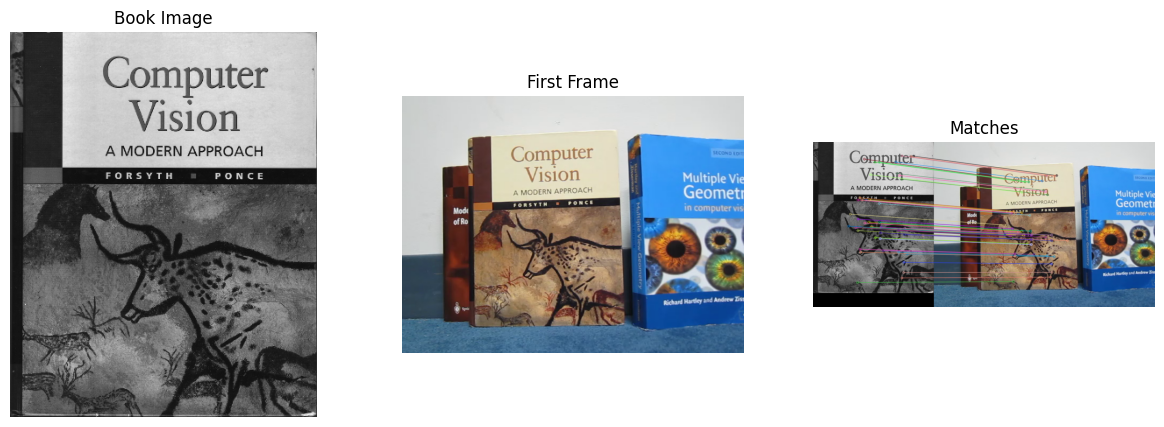

Computed Homography Matrix:
 [[ 7.71105562e-01  2.08425653e-03  1.19632939e+02]
 [-5.23082702e-02  7.76316702e-01  7.78199643e+01]
 [-9.56621235e-05 -7.86759153e-05  1.00000000e+00]]


In [38]:
# Grab the first frame
ret, frame = book_video.read()
if ret:
    # Test SIFT and plot
    src_pts, dst_pts, kp1, des1 = get_SIFT_matches(book_img, frame, plot=True)
    
    # Test Homography
    H = compute_homography(src_pts, dst_pts)
    print("Computed Homography Matrix:\n", H)
    
    # Reset video to the beginning for the main loop
    book_video.set(cv.CAP_PROP_POS_FRAMES, 0)

In [39]:
fps = book_video.get(cv.CAP_PROP_FPS)
width = int(book_video.get(cv.CAP_PROP_FRAME_WIDTH))
height = int(book_video.get(cv.CAP_PROP_FRAME_HEIGHT))
out = cv.VideoWriter("ar_output.mp4", cv.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

# Precompute book features once
sift = cv.SIFT_create()
kp1, des1 = sift.detectAndCompute(book_img, None)

while True:
    ret, frame = book_video.read()
    ret_ar, frame_ar = ar_video.read()
    if not ret or not ret_ar:
        break
    
    h_ar, w_ar = frame_ar.shape[:2]
    ar_aspect = w_ar / h_ar

    # Crop AR video to match book aspect ratio
    if ar_aspect > aspect_ratio:
        new_w = int(h_ar * aspect_ratio)
        cropped_ar = frame_ar[:, (w_ar - new_w) // 2 : (w_ar - new_w) // 2 + new_w]
    else:
        new_h = int(w_ar / aspect_ratio)
        cropped_ar = frame_ar[(h_ar - new_h) // 2 : (h_ar - new_h) // 2 + new_h, :]

    cropped_ar = cv.resize(cropped_ar, (w, h))

    try:
        # Pass precomputed kp1/des1 to save processing time
        src_pts, dst_pts, _, _ = get_SIFT_matches(book_img, frame, kp1=kp1, des1=des1)
        H = compute_homography(src_pts, dst_pts)
        result = overlay_ar_frame(frame, cropped_ar, H, w, h)
    except Exception as e:
        print(f"Skipping frame: {e}")
        result = frame

    out.write(result)

out.release()
book_video.release()
ar_video.release()
print("AR Video generation complete!")

AR Video generation complete!


In [40]:
# Load the two overlapping images
img1 = cv.imread("view1.jpg") # Left image (Anchor)
img2 = cv.imread("view2.jpg") # Right image (To be warped)

# Convert to RGB for matplotlib
img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img2_rgb = cv.cvtColor(img2, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1), plt.title("View 1 (Anchor)"), plt.imshow(img1_rgb), plt.axis('off')
plt.subplot(1, 2, 2), plt.title("View 2 (Source to Warp)"), plt.imshow(img2_rgb), plt.axis('off')
plt.show()

error: OpenCV(4.8.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:182: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [ ]:
# Get SIFT matches (we want img2 points to map to img1)
src_pts_mosaic, dst_pts_mosaic, _, _ = get_sift_matches(img2, img1, plot=True)

# Compute the homography matrix H that transforms img2 to img1
H_mosaic = compute_homography(src_pts_mosaic, dst_pts_mosaic)

print("Mosaic Homography Matrix:\n", H_mosaic)

In [ ]:
import numpy as np
import cv2 as cv

def forward_warp(img, H, out_shape):
    """
   Note: Maps source pixels directly to destination pixels. Often leaves "holes" 
    due to fractional coordinate rounding.
    """
    out_h, out_w = out_shape[:2]
    out_img = np.zeros((out_h, out_w, img.shape[2]), dtype=np.uint8)
    
    h, w = img.shape[:2]
    
    # 1. Create a grid of all source image coordinates
    X, Y = np.meshgrid(np.arange(w), np.arange(h))
    pts_src = np.stack([X.ravel(), Y.ravel(), np.ones_like(X).ravel()])
    
    # 2. Multiply by Homography matrix to find destination coordinates
    pts_dst = H @ pts_src
    
    # 3. Divide by Z (homogeneous coordinate conversion) and round to nearest integer pixel
    dst_x = np.round(pts_dst[0] / pts_dst[2]).astype(int)
    dst_y = np.round(pts_dst[1] / pts_dst[2]).astype(int)
    
    # 4. Filter out any points that got warped completely off the canvas
    valid = (dst_x >= 0) & (dst_x < out_w) & (dst_y >= 0) & (dst_y < out_h)
    
    # 5. Push source pixels to destination canvas
    out_img[dst_y[valid], dst_x[valid]] = img[Y.ravel()[valid], X.ravel()[valid]]
    
    return out_img


def inverse_warp(img, H, out_shape, offset_x=0, offset_y=0):
    """
    REQUIRED BY ASSIGNMENT: Implements inverse warping with bilinear interpolation.
    """
    out_h, out_w = out_shape[:2]
    out_img = np.zeros((out_h, out_w, img.shape[2]), dtype=np.uint8)
    h, w = img.shape[:2]
    
    H_inv = np.linalg.inv(H)
    
    # 1. Create a grid of all DESTINATION coordinates
    X, Y = np.meshgrid(np.arange(out_w), np.arange(out_h))
    
    # Shift grid if the panorama expands into negative coordinates
    X_shifted = X + offset_x
    Y_shifted = Y + offset_y
    pts_dst = np.stack([X_shifted.ravel(), Y_shifted.ravel(), np.ones_like(X).ravel()])
    
    # 2. Multiply by INVERSE Homography to find where they came from in the source image
    pts_src = H_inv @ pts_dst
    src_x = pts_src[0] / pts_src[2]
    src_y = pts_src[1] / pts_src[2]
    
    # 3. Filter out points that map outside the bounds of the source image
    valid = (src_x >= 0) & (src_x < w - 1) & (src_y >= 0) & (src_y < h - 1)
    
    # 4. Bilinear Interpolation
    sx, sy = src_x[valid], src_y[valid]
    x0, y0 = np.floor(sx).astype(int), np.floor(sy).astype(int)
    x1, y1 = x0 + 1, y0 + 1
    
    # Distance weights 
    # (Using [:, np.newaxis] to allow broadcasting across all 3 RGB channels)
    wa = ((x1 - sx) * (y1 - sy))[:, np.newaxis]
    wb = ((x1 - sx) * (sy - y0))[:, np.newaxis]
    wc = ((sx - x0) * (y1 - sy))[:, np.newaxis]
    wd = ((sx - x0) * (sy - y0))[:, np.newaxis]
    
    # Grab the 4 neighboring pixels for each valid point
    Ia = img[y0, x0]
    Ib = img[y1, x0]
    Ic = img[y0, x1]
    Id = img[y1, x1]
    
    # Blend them and assign to the destination image
    out_img[Y.ravel()[valid], X.ravel()[valid]] = np.round(wa*Ia + wb*Ib + wc*Ic + wd*Id).astype(np.uint8)
    
    return out_img

In [ ]:
def create_custom_mosaic(img1, img2, H):
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]

    # Find bounding box
    corners2 = np.float32([[0, 0], [w2, 0], [w2, h2], [0, h2]]).reshape(-1, 1, 2)
    warped_corners2 = cv.perspectiveTransform(corners2, H).reshape(4, 2)
    all_corners = np.vstack(([[0, 0], [w1, 0], [w1, h1], [0, h1]], warped_corners2))
    
    x_min, y_min = np.int32(np.floor(all_corners.min(axis=0)))
    x_max, y_max = np.int32(np.ceil(all_corners.max(axis=0)))

    # Calculate translations
    tx, ty = -x_min, -y_min
    out_w, out_h = x_max - x_min, y_max - y_min
    out_shape = (out_h, out_w)

    # 1. Use your REQUIRED custom inverse warp function
    warped_img2 = inverse_warp(img2, H, out_shape, offset_x=-tx, offset_y=-ty)

    # 2. Create canvas and place Anchor image
    canvas = np.zeros((out_h, out_w, 3), dtype=np.uint8)
    canvas[ty:ty+h1, tx:tx+w1] = img1

    # 3. Combine them (overlaying the warped image where the canvas is currently black)
    mask = (warped_img2 > 0)
    canvas[mask] = warped_img2[mask]

    return canvas

# Assuming H_mosaic was calculated in Cell 6
final_mosaic = create_custom_mosaic(img1_rgb, img2_rgb, H_mosaic)

plt.figure(figsize=(15, 8))
plt.title("Mosaic (Using Custom Inverse Warp)")
plt.imshow(final_mosaic)
plt.axis('off')
plt.show()